In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_telco_churn.csv")

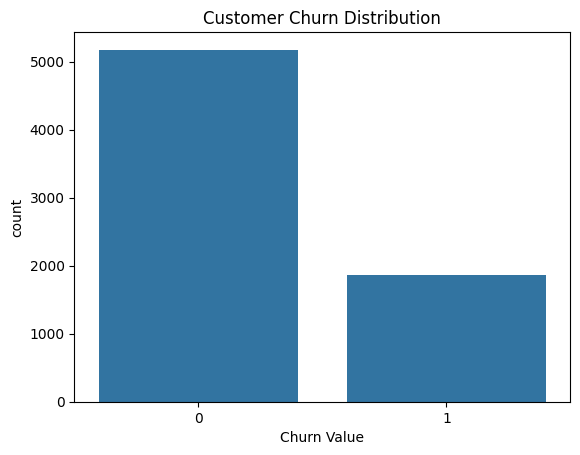

In [2]:
sns.countplot(x='Churn Value', data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [3]:
Churn_rate = df['Churn Value'].value_counts(normalize=True) * 100
print(Churn_rate)

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64


Tenure vs Churn

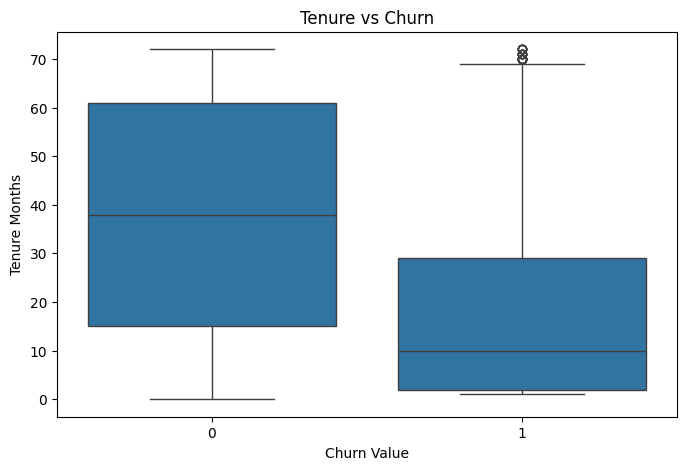

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(
     x='Churn Value',
    y='Tenure Months',
    data=df
)
plt.title("Tenure vs Churn")
plt.show()

Monthly Charges vs Churn

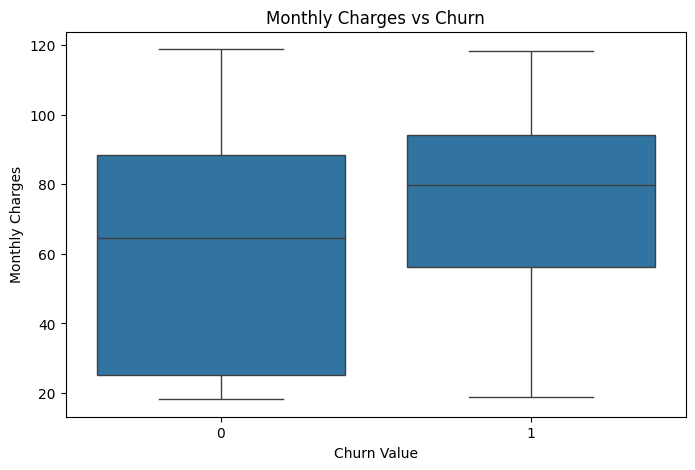

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Value',
    y='Monthly Charges',
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

Total Charges Distribution

In [ ]:
sns.histplot(
    data=df,
    x='Total Charges',
    hue='Churn Value',
    kde=True
)

plt.title("Total Charges Distribution")
plt.show()

Contract Type vs Churn

In [ ]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Value'],
    normalize='index'
)

contract_churn.plot(kind='bar', stacked=True)

plt.title("Contract Type vs Churn")
plt.ylabel("Proportion")
plt.show()

Internet Service vs Churn

In [ ]:
internet_churn = pd.crosstab(
    df['Internet Service'],
    df['Churn Value'],
    normalize='index'
)

internet_churn.plot(kind='bar', stacked=True)

plt.title("Internet Service vs Churn")
plt.ylabel("Proportion")
plt.show()

Payment Method vs Churn

In [ ]:
payment_churn = pd.crosstab(
    df['Payment Method'],
    df['Churn Value'],
    normalize='index'
)

payment_churn.plot(kind='bar', stacked=True)

plt.title("Payment Method vs Churn")
plt.ylabel("Proportion")
plt.show()

Encode Categories

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")
plt.show()

High-Risk Customer Segments

In [ ]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['Tenure Months'] < 12)
]

high_risk.shape

In [ ]:
high_risk['Churn Value'].mean()